# Test of Time-dependent Dissipative Dynamics

The purpose of this notebook is to test and visually verify the correct implementation of dynamics with time-dependent dissipators. We look at a single qubit, driven by a GKSL generator with a single discrete time dependent dissipator that flips between pumping and dissipating dynamics periodically.

## 1. Imports

In [1]:
from qsim.dynamics import GKSLGenerator, RK4Propagator, Dynamics
from qsim.logging import Logger
from qsim.operator import sigmaMinus, sigmaPlus, I, TOperator, sigmaZ
from qsim.state import Detector, DensityMatrix

import numpy as np

import math
import matplotlib.pyplot as plt

## 2. Configure Dynamics

In [2]:
# System dimension
d = 2

# Dynamic switch frequency
omega = 6

In [3]:
f = (lambda t: math.floor((t/omega)%2))

Text(0.5, 1.0, 'Periodic Driving Function')

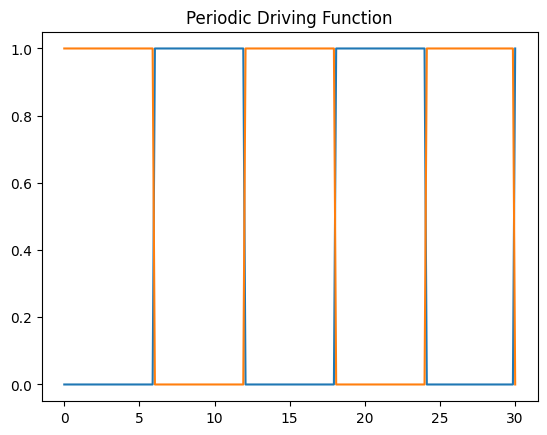

In [4]:
ts = np.linspace(0, 30, 200)
plt.plot(ts, list(map(f, ts)))
plt.plot(ts, list(map((lambda t: 1-f(t)), ts)))
plt.title('Periodic Driving Function')

In [5]:
H = I(d)
L1 =  f * TOperator.from_static(sigmaMinus) + (lambda t: 1-f(t))  * TOperator.from_static(sigmaPlus)

In [6]:
generator = GKSLGenerator(H=H, jumps=[L1])
propagator = RK4Propagator()

In [7]:
dynamics = Dynamics(propagator, generator)

## 3. Logger Setup

In [8]:
detector = Detector(sigmaZ)

In [9]:
logger = Logger([detector])
dynamics.addCallback(logger.log)

## 4. Evolution

In [10]:
initial_state = DensityMatrix(np.array([[1,0],[0,0]]))

In [11]:
dynamics.evolve(initial_state, ts=list(ts))

## 5. Visualisation

Text(0.5, 0, '$t$')

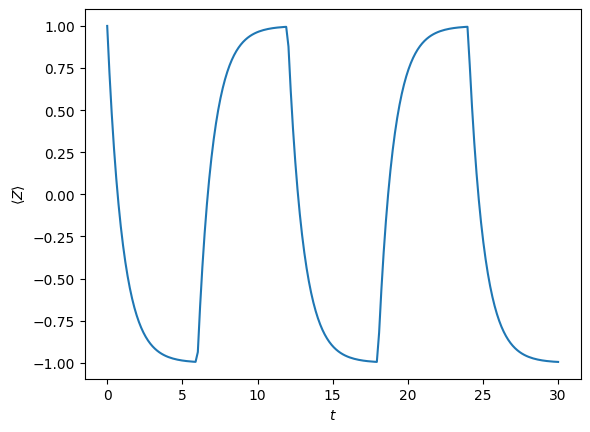

In [12]:
plt.plot(ts, logger.observable_log[detector].values())
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')

## 6. Heisenberg Evolution

In [13]:
generator = GKSLGenerator(H=H, jumps=[L1])
propagator = RK4Propagator()

In [14]:
heisenberg_dynamics = Dynamics(propagator, generator)

In [16]:
initial_state = DensityMatrix(np.array([[1,0],[0,0]]))

In [17]:
heisenberg_dynamics.evolveOperator(sigmaZ, ts=list(ts))

ValueError: Evolution time 30.0 is more than initial time 0

In [ ]:
generator.onOperator(-I(2), 7)

Operator(
[[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
)

/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


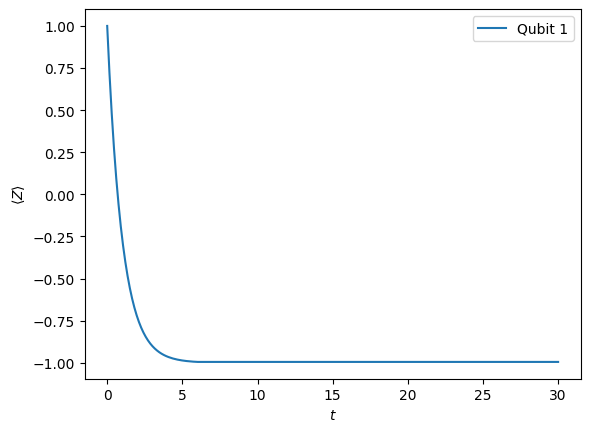

In [ ]:
plt.plot(ts, [(op @ initial_state).trace() for op in logger_composite.state_log.values()], label='Qubit 1')
#plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()